In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import sys
import os
from datetime import datetime

from pathlib import Path
import glob
import logging
import dask
import calendar
import iris
from scipy import special
from scipy.interpolate import griddata
from scipy.interpolate import RegularGridInterpolator
import scipy.special
from scipy.stats import mannwhitneyu
from scipy.stats import gaussian_kde
from math import sin, cos, sqrt, atan2, radians, asin
from typing import TypedDict, Optional
import functools

#plotting libraries
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.cm as cm
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, TwoSlopeNorm, BoundaryNorm, Normalize
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
import matplotlib.path as mpath
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.feature as cfeature

# import functions
sys.path.append(os.path.join(r"/home/563/ac9768/PhD")) 
sys.path.append(os.path.join(r"/home/563/ac9768/PhD/Plotting_scripts")) 
from Plotting_scripts import get_subplot_axes, plot_data_on_axes, plot_violins_seasons, plot_violins_regions
from Plotting_scripts import latitude_weighting, time_weighting
from Plotting_scripts import plot_polar_ndjf_plots, plot_polar_single
from Plotting_scripts import monthly_flux_to_TgS
from Plotting_scripts import get_grid_size

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2    
# %reload_ext autoreload

In [2]:
from dask_setup import setup_dask_client 
from dask_setup import recommend_chunks
client, cluster, dask_tmp = setup_dask_client(mode="interactive", workload_type="auto")
warnings.simplefilter(action='ignore', category=FutureWarning)

INFO     [client] Interactive cluster mode — using already-allocated nodes
INFO     [multinode] Interactive cluster: single node, using LocalCluster (node=gadi-cpu-bdw-0763.gadi.nci.org.au)
INFO     [client] Starting Dask client setup (workload_type=auto | environment=jupyter)
INFO     [resources] Resources detected via PBS (total_cores=28 | total_mem_gib=252.0)
INFO     [client] workload_type='auto' resolved via dataset inspection (workload_type=mixed)


INFO     [client] Temp/spill dir: /jobfs/169515369.gadi-pbs/dask-981793
INFO     [client] Workers: 14 | threads/worker: 2 | processes: True
INFO     [client] Mem: total ~252.0 GiB | usable ~202.0 GiB | per-worker ~14.4 GiB
INFO     [client] Compression: spill=auto | comm=False
INFO     [client] Dask client ready


[setup_dask_client] Configuration summary
temp/spill dir: /jobfs/169515369.gadi-pbs/dask-981793
Workers: 14 | threads/worker: 2 | processes: True
Memory: total ~252.0 GiB | usable ~202.0 GiB | per-worker ~14.4 GiB
Compression: spill=auto | comm=False


In [3]:
# read in bathymetry files
ds_full = xr.open_dataset('/home/563/ac9768/GBR/Aus_Bathymetry/ETOPO2v2c_f4.GQp62nWv.nc.part',engine="netcdf4")
ds_bath = ds_full.sel(x=slice(140,155),y=slice(-22,-11))

# read in satellite files
def him8_files(directory):
    file_paths = []
    for root, _, files in os.walk(directory):
        for file in files:
            if file.endswith("_ch13BT_regridded_2kmres.nc"):  
                file_paths.append(os.path.join(root, file))
    return file_paths
directory = "/g/data/q90/ac9768/GBR/him8"
files = him8_files(directory)

In [4]:
def utc_to_lst_shift(ds, longitude_center: float):
    """
    Shift xarray data from UTC to Local Solar Time by offsetting the 
    time coordinate. Adds the LST offset to time labels directly —
    does NOT roll/wrap data values.

    Args:
        ds:               xarray Dataset or DataArray with a 'time' dimension.
        longitude_center: Representative longitude of the region (decimal degrees).

    Returns:
        Dataset/DataArray with time coordinate relabelled to LST.
    """
    offset_hours = round(longitude_center * 4 / 60)
    offset = pd.Timedelta(hours=offset_hours)

    # Shift only the time coordinate labels, data values stay aligned
    ds_lst = ds.assign_coords(time=ds.time + offset)
    return ds_lst

In [5]:
# define 12 LST wind regime definition
def wind_times(barra_regime_ds: xr.Dataset, longitude_center: float):
    """
    Classify wind direction at LST solar noon (hour=12), then assign
    all hours of that day to the same wind regime.

    Args:
        barra_regime_ds:  xarray Dataset with 'wind_dir' and 'time' dimension.
        longitude_center: Representative longitude for LST conversion.

    Returns:
        ne, se, sw, nw: arrays of datetime64 timestamps (all hours) 
                        belonging to each wind regime day.
    """
    # 1. Shift full dataset to LST
    ds_lst = utc_to_lst_shift(barra_regime_ds, longitude_center)

    # 2. Extract wind_dir and compute (needed for boolean indexing)
    winds = ds_lst.wind_dir.compute()

    # 3. Select only solar noon (LST hour=12) for regime classification
    winds_noon = winds.sel(time=winds.time.dt.hour == 12)

    # 4. Classify noon wind direction → get dates (not full timestamps)
    ne_dates = winds_noon.time.values[(winds_noon.values >= 0)   & (winds_noon.values <= 90)]
    se_dates = winds_noon.time.values[(winds_noon.values > 90)   & (winds_noon.values <= 180)]
    sw_dates = winds_noon.time.values[(winds_noon.values > 180)  & (winds_noon.values <= 270)]
    nw_dates = winds_noon.time.values[(winds_noon.values > 270)  & (winds_noon.values <= 360)]

    # 5. Convert noon timestamps → date-only for day matching
    def noon_to_all_hours(regime_noon_times):
        """Given noon timestamps, return all LST timestamps on those days."""
        regime_dates = set(
            pd.Timestamp(t).date() for t in regime_noon_times
        )
        all_times = pd.DatetimeIndex(winds.time.values)
        mask = all_times.normalize().map(lambda d: d.date() in regime_dates)
        return winds.time.values[mask]

    ne_lst = noon_to_all_hours(ne_dates)
    se_lst = noon_to_all_hours(se_dates)
    sw_lst = noon_to_all_hours(sw_dates)
    nw_lst = noon_to_all_hours(nw_dates)

    # 6. Convert LST timestamps back to UTC by subtracting the offset
    offset_hours = round(longitude_center * 4 / 60)
    offset = pd.Timedelta(hours=offset_hours)

    # Shift only the time coordinate labels, data values stay aligned
    # ds_lst = ds.assign_coords(time=ds.time + offset)

    
    # offset_hours = round(longitude_center * 4 / 60)
    # offset = np.timedelta64(offset_hours, 'h')

    ne = ne_lst - offset
    se = se_lst - offset
    sw = sw_lst - offset
    nw = nw_lst - offset

    return ne, se, sw, nw


# --- Usage ---
lon_cairns = (144.27374 + 147.09222) / 2  # ≈ 145.68°E


In [6]:
ds_barra = xr.open_mfdataset('/g/data/q90/ac9768/GBR/barra-2/barra-2_850hPa_winds_cairns.nc',engine="netcdf4")
ds_barra = ds_barra.sortby('time')
ds_selected = ds_barra.sel(time=slice('2016-01-01', '2020-04-01'))
barra = ds_selected.sel(time=~(ds_selected['time.month'] == 4))
ne, se, sw, nw = wind_times(barra, lon_cairns)

In [7]:
def utc_to_lst_shift_him8(ds, longitude_center: float):
    """
    Shift xarray data from UTC to Local Solar Time by offsetting the 
    time coordinate. Adds the LST offset to time labels directly —
    does NOT roll/wrap data values.

    Args:
        ds:               xarray Dataset or DataArray with a 'time' dimension.
        longitude_center: Representative longitude of the region (decimal degrees).

    Returns:
        Dataset/DataArray with time coordinate relabelled to LST.
    """
    offset_hours = round(longitude_center * 4 / 60)  # degrees → minutes → hours
    # Shift data values along the time axis (dask-safe, no compute triggered)
    ds_shifted = ds.roll(hour=offset_hours, roll_coords=True)
    return ds_shifted

In [8]:
def utc_to_lst_shift_him8(ds, longitude_center: float):
    """
    Shift xarray data from UTC to Local Solar Time by offsetting the 
    time coordinate. Adds the LST offset to time labels directly —
    does NOT roll/wrap data values.
    Args:
        ds:               xarray Dataset or DataArray with a 'time' or 'hour' dimension.
        longitude_center: Representative longitude of the region (decimal degrees).
    Returns:
        Dataset/DataArray with time/hour coordinate relabelled to LST.
    """
    offset_hours = round(longitude_center * 4 / 60)  # degrees → minutes → hours
    
    # Determine which dimension to shift (time or hour)
    if 'hour' in ds.dims:
        dim_name = 'hour'
    elif 'time' in ds.dims:
        dim_name = 'time'
    else:
        raise ValueError("Dataset must have 'hour' or 'time' dimension")
    
    # Roll data and reset coordinate to 0-23 range
    ds_shifted = ds.roll({dim_name: offset_hours}, roll_coords=True)
    
    # Reset hour coordinate to 0-23
    new_coord = (ds_shifted[dim_name].values + offset_hours) % 24
    ds_shifted = ds_shifted.assign_coords({dim_name: new_coord})
    
    return ds_shifted

# Compute BT < 235 K

In [39]:
def read_netcdf_him8(file_path, wind_times, longitude_center=145.68298):
    """
    Extract and analyze HimawariI-8 brightness temperature data for a specific region and time period.
    
    Selects brightness temperature (ch13BT) data over the Cairns region, filters by specified
    wind regime times, and calculates convective statistics based on a 235 K threshold.
    
    Parameters
    ----------
    file_path : str
        Path to HimawariI-8 netCDF file(s). Supports wildcards for multiple files.
    wind_times : list or array-like
        Time values to select from the dataset (nearest neighbor matching).
    
    Returns
    -------
    dict
        Dictionary containing:
        - 'bt_data': xr.DataArray of brightness temperature (K)
        - 'count_cold': int, number of points < 235 K
        - 'pct_cold_total': float, percentage of all points < 235 K
        - 'pct_cold_hourly': xr.DataArray, percentage of points < 235 K per hour
    """
    with xr.open_mfdataset(file_path, engine="h5netcdf", chunks="auto") as ds:
        bt_under_barra_cairns_regimes = ds.ch13BT.sel(
            lat=slice(-17, -16.6)
        ).sel(time=wind_times, method="nearest")
    
    # Count points < 235 K
    count_cold = (bt_under_barra_cairns_regimes < 235).sum().values
    total_points = bt_under_barra_cairns_regimes.size
    pct_cold_total = (count_cold / total_points) * 100
    
    # Percentage of points < 235 K per hour
    # pct_cold_hourly = (
    #     (bt_under_barra_cairns_regimes < 235)
    #     .groupby(bt_under_barra_cairns_regimes.time.dt.hour)
    #     .sum() / bt_under_barra_cairns_regimes.groupby(
    #         bt_under_barra_cairns_regimes.time.dt.hour
    #     ).count()
    # ) * 100

    # Percentage of points < 235 K per hour (lon x hour, mean over lat)
    pct_cold_hourly = (
        (bt_under_barra_cairns_regimes < 235)
        .groupby(bt_under_barra_cairns_regimes.time.dt.hour)
        .sum(dim=['lat', 'time']) / 
        bt_under_barra_cairns_regimes.groupby(
            bt_under_barra_cairns_regimes.time.dt.hour
        ).count(dim=['lat', 'time'])
    ) * 100

    # Convert to Local Solar Time
    pct_cold_hourly_lst = utc_to_lst_shift_him8(pct_cold_hourly, longitude_center)
    
    return {
        'bt_data': bt_under_barra_cairns_regimes,
        'size_total': total_points,
        'count_cold': count_cold,
        'pct_cold_total': pct_cold_total,
        'pct_cold_hourly': pct_cold_hourly_lst
    }

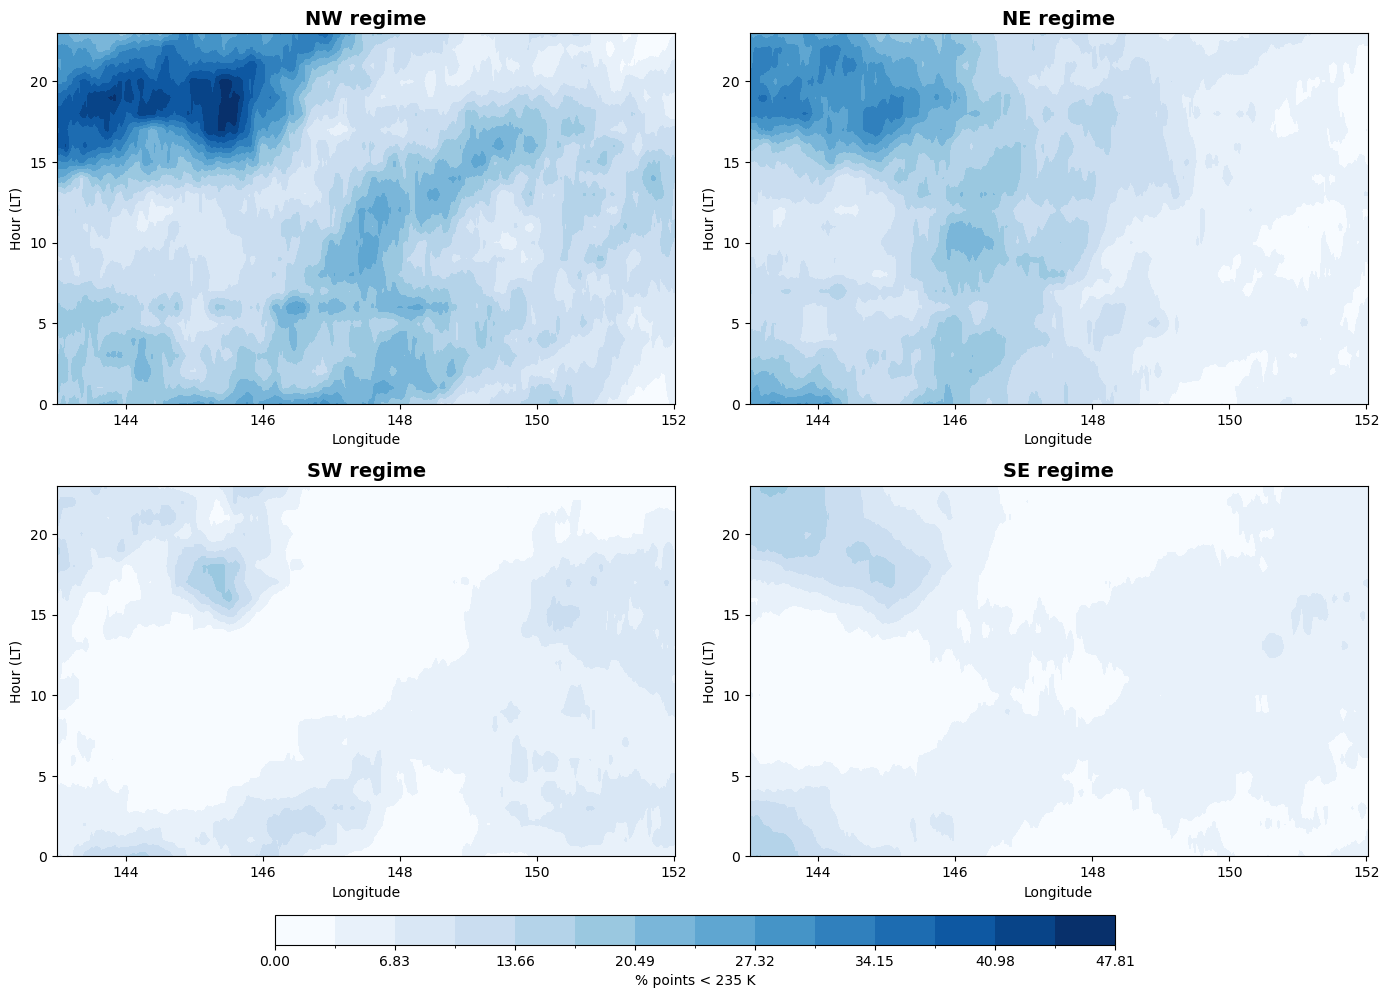

In [42]:
# Read data for all regimes
regimes = {'nw': nw, 'ne': ne, 'sw': sw, 'se': se}
results = {}
for regime_name, regime_times in regimes.items():
    results[regime_name] = read_netcdf_him8(files, regime_times)

# Create 2x2 figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

regime_labels = ['NW', 'NE', 'SW', 'SE']
regime_keys = ['nw', 'ne', 'sw', 'se']

# Get global vmin/vmax for consistent colorbar
vmin = min([results[r]['pct_cold_hourly'].min().values for r in regime_keys])
vmax = max([results[r]['pct_cold_hourly'].max().values for r in regime_keys])

for idx, (regime_key, label) in enumerate(zip(regime_keys, regime_labels)):
    ax = axes[idx]
    
    im = results[regime_key]['pct_cold_hourly'].plot.contourf(
        ax=ax,
        cmap='Blues',
        x='lon',
        y='hour',
        levels=15,
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )
    
    ax.set_title(f'{label} regime', fontsize=14, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Hour (LT)')

# Add single colorbar
cbar_ax = fig.add_axes([0.2, 0.05, 0.6, 0.03])
fig.colorbar(im, cax=cbar_ax, orientation='horizontal', label='% points < 235 K')

plt.tight_layout(rect=[0, 0.08, 1, 1])
# plt.savefig('pct_cold_by_regime_hovmoller.png', dpi=300, bbox_inches='tight')
plt.show()

# Compute BT thresholds

In [15]:
# make function output % for different thresholds
def compute_h8_thresholds(file_path, wind_times, longitude_center=145.68298):
    """
    Extract and analyze HimawariI-8 brightness temperature data for a specific region and time period.
    
    Selects brightness temperature (ch13BT) data over the Cairns region, filters by specified
    wind regime times, and calculates convective statistics based on brightness temperature thresholds.
    
    Parameters
    ----------
    file_path : str
        Path to HimawariI-8 netCDF file(s). Supports wildcards for multiple files.
    wind_times : list or array-like
        Time values to select from the dataset (nearest neighbor matching).
    longitude_center : float, optional
        Representative longitude of the region in decimal degrees (default: 145.68298 for Cairns).
    
    Returns
    -------
    dict
        Dictionary containing:
        - 'bt_data': xr.DataArray of brightness temperature (K)
        - 'size_total': int, total number of points
        - 'count_cold': int, number of points < 235 K
        - 'pct_cold_total': float, percentage of all points < 235 K
        - 'pct_immature_hourly': xr.DataArray, percentage of points > 253 K per hour (lon x hour, LST)
        - 'pct_mature_hourly': xr.DataArray, percentage of points 213-253 K per hour (lon x hour, LST)
        - 'pct_deep_hourly': xr.DataArray, percentage of points < 213 K per hour (lon x hour, LST)
    """
    with xr.open_mfdataset(file_path, engine="h5netcdf", chunks="auto") as ds:
        bt_under_barra_cairns_regimes = ds.ch13BT.sel(
            lat=slice(-17, -16.6)
        ).sel(time=wind_times, method="nearest")
    
    total_points = bt_under_barra_cairns_regimes.size
    
    # Count points < 235 K
    count_cold = (bt_under_barra_cairns_regimes < 235).sum().values
    pct_cold_total = (count_cold / total_points) * 100
    
    # Percentage of points < 235 K per hour (lon x hour, mean over lat)
    pct_immature_hourly = (
        (bt_under_barra_cairns_regimes > 293)
        # ((bt_under_barra_cairns_regimes >= 273) & (bt_under_barra_cairns_regimes <= 283))
        .groupby(bt_under_barra_cairns_regimes.time.dt.hour)
        .sum(dim=['lat', 'time']) / 
        bt_under_barra_cairns_regimes.groupby(
            bt_under_barra_cairns_regimes.time.dt.hour
        ).count(dim=['lat', 'time'])
    ) * 100
    
    # Percentage of mature systems (213-253 K) per hour
    pct_mature_hourly = (
        ((bt_under_barra_cairns_regimes >= 213) & (bt_under_barra_cairns_regimes <= 253))
        .groupby(bt_under_barra_cairns_regimes.time.dt.hour)
        .sum(dim=['lat', 'time']) / 
        bt_under_barra_cairns_regimes.groupby(
            bt_under_barra_cairns_regimes.time.dt.hour
        ).count(dim=['lat', 'time'])
    ) * 100
    
    # Percentage of deep convection (< 213 K) per hour
    pct_deep_hourly = (
        (bt_under_barra_cairns_regimes < 213)
        .groupby(bt_under_barra_cairns_regimes.time.dt.hour)
        .sum(dim=['lat', 'time']) / 
        bt_under_barra_cairns_regimes.groupby(
            bt_under_barra_cairns_regimes.time.dt.hour
        ).count(dim=['lat', 'time'])
    ) * 100
    
    # Convert to Local Solar Time
    pct_immature_hourly_lst = utc_to_lst_shift_him8(pct_immature_hourly, longitude_center)
    pct_mature_hourly_lst = utc_to_lst_shift_him8(pct_mature_hourly, longitude_center)
    pct_deep_hourly_lst = utc_to_lst_shift_him8(pct_deep_hourly, longitude_center)
    
    return {
        'bt_data': bt_under_barra_cairns_regimes,
        'size_total': total_points,
        'count_cold': count_cold,
        'pct_cold_total': pct_cold_total,
        'pct_immature_hourly': pct_immature_hourly_lst,
        'pct_mature_hourly': pct_mature_hourly_lst,
        'pct_deep_hourly': pct_deep_hourly_lst
    }

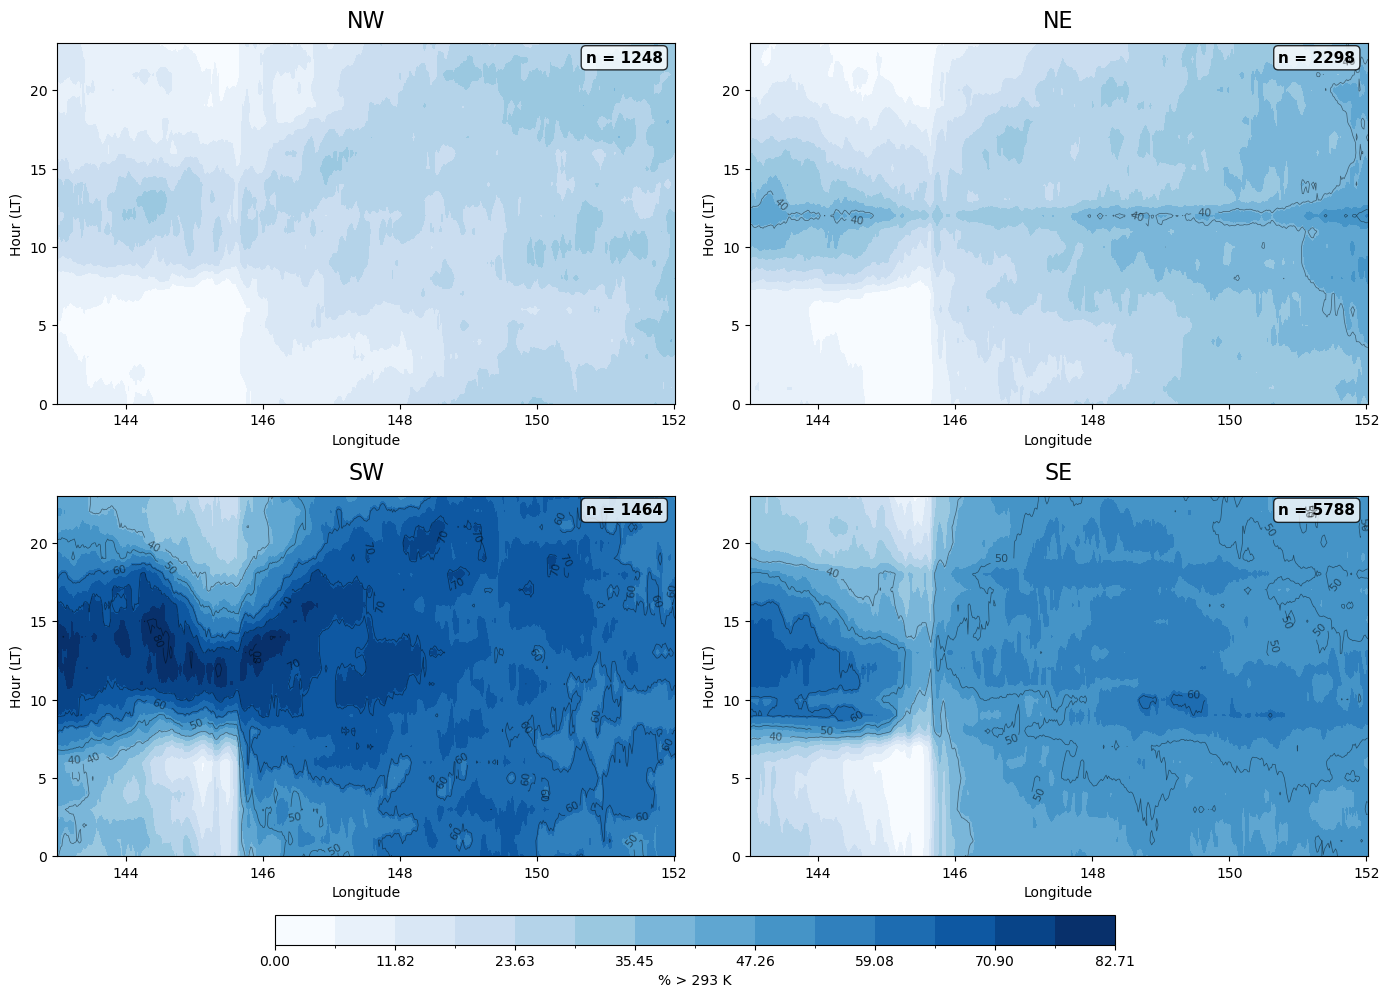

In [16]:
import matplotlib.pyplot as plt

# Read data for all regimes
regimes = {'nw': nw, 'ne': ne, 'sw': sw, 'se': se}
results = {}
for regime_name, regime_times in regimes.items():
    results[regime_name] = compute_h8_thresholds(files, regime_times)
    
# ---------------------------------------------------
plot_threshold = 'pct_immature_hourly'
label_cbar = '% > 293 K'#'% deep convective regions (< 213 K)'#'% immature convective regions (> 253 K)'#
label_levels = [40,50,60,70,80,90] #[5,10,15, 20,25]#[40,50,60,70,80,90]#[10,20,30,40] #[5,10,15, 20,25] #
# ---------------------------------------------------

# Create 2x2 figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

regime_labels = ['NW', 'NE', 'SW', 'SE']
regime_keys = ['nw', 'ne', 'sw', 'se']

# Get global vmin/vmax for consistent colorbar
vmin = min([results[r][plot_threshold].min().values for r in regime_keys])
vmax = max([results[r][plot_threshold].max().values for r in regime_keys])

# Create levels for contours
levels = np.linspace(vmin, vmax, 15)

for idx, (regime_key, label) in enumerate(zip(regime_keys, regime_labels)):
    ax = axes[idx]
    
    im = results[regime_key][plot_threshold].plot.contourf(
        ax=ax,
        cmap='Blues',
        x='lon',
        y='hour',
        levels=levels,
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )
    
    # Add contour lines with labels at 10, 20, 30, 40
    cs = ax.contour(
        results[regime_key][plot_threshold].lon,
        results[regime_key][plot_threshold].hour,
        results[regime_key][plot_threshold].values,
        levels=label_levels,
        colors='black',
        linewidths=0.5,
        alpha=0.5
    )
    ax.clabel(cs, inline=True, fontsize=8, fmt='%.0f')
    
    # Get number of time steps
    n_samples = results[regime_key]['bt_data'].time.size
    
    # Add text in top right corner
    ax.text(0.98, 0.98, f'n = {n_samples}', 
            transform=ax.transAxes, 
            fontsize=11, 
            fontweight='bold',
            verticalalignment='top', 
            horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_title(f'{label}', fontsize=16, y=1.02)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Hour (LT)')

# Add single colorbar
cbar_ax = fig.add_axes([0.2, 0.05, 0.6, 0.03])
fig.colorbar(im, cax=cbar_ax, orientation='horizontal', label=label_cbar)

plt.tight_layout(rect=[0, 0.08, 1, 1])
# plt.savefig(f'/home/563/ac9768/GBR/scripts/Paper_figures/F07_{plot_threshold}_by_regime_hovmoller.png', dpi=300, bbox_inches='tight')
plt.show()

In [40]:
result = read_netcdf_him8(files, ne)
print(f"Total points < 235 K: {result['count_cold']}")
print(f"Percentage of all points < 235 K: {result['pct_cold_total']:.2f}%")
print(result['pct_cold_hourly'])

Total points < 235 K: 2991003
Percentage of all points < 235 K: 11.79%
<xarray.DataArray 'ch13BT' (hour: 24, lon: 502)> Size: 96kB
dask.array<rechunk-merge, shape=(24, 502), dtype=float64, chunksize=(24, 502), chunktype=numpy.ndarray>
Coordinates:
  * hour     (hour) int64 192B 0 1 2 3 4 5 6 7 8 ... 15 16 17 18 19 20 21 22 23
  * lon      (lon) float64 4kB 143.0 143.0 143.0 143.1 ... 152.0 152.0 152.0
Attributes:
    regrid_method:  bilinear


Text(0, 0.5, 'Hour (LT)')

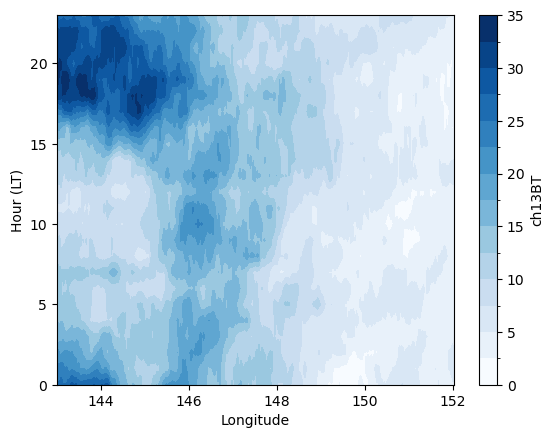

In [41]:
result['pct_cold_hourly'].plot.contourf(cmap='Blues', x='lon', y='hour', levels=15)
plt.xlabel('Longitude')
plt.ylabel('Hour (LT)')

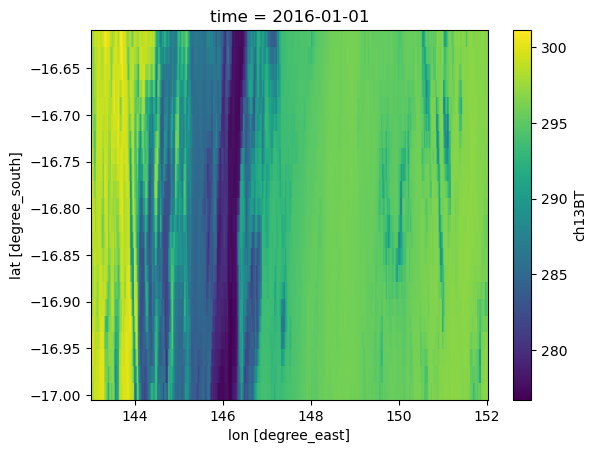

In [13]:
ne_him_mean.isel(time=0).plot()